# CTGAN for the high level feature dataset - final solution

In this approach, we only synthetize the features that are actually used later for the low-level GAN. This is just a subset of all te features we identified earlier, chosen based on what we think the GAN can use the most

In [ ]:
import pandas as pd

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
high_level_features = pd.read_csv('https://raw.githubusercontent.com/imets01/synthetic_network_data_gen/refs/heads/anna/high_level_features/dataset/all_captures_dataset.csv')

In [ ]:
high_level_features[high_level_features['handshake_duration']<0]

,file_id,implementation,initial_ip_client,initial_ip_server,initial_port_client,initial_port_server,time_first,time_last,connection_duration,version_negotiation_occurred,retry_occurred,new_connection_ids_issued_server,retired_cid_count_client,retired_cid_count_server,new_connection_ids_issued_client,migration_type,first_path_validation_response_latency,path_validation_initiated,connection_close_type,bytes_sent_client,bytes_sent_server,packets_sent_client,packets_sent_server,quic_packets_sent_client,quic_packets_sent_server,handshake_duration,time_to_migration,migration_duration,packets_before_migration,app_data_bytes_before_migration,padding_bytes_in_validation_pc,padding_bytes_in_validation_pr,mtu,total_bidi_streams_client_init,total_bidi_streams_server_init,total_udi_streams_client_init,total_udi_streams_server_init,bytes_bidi_streams_client_init_client_sent,bytes_bidi_streams_client_init_server_sent,bytes_bidi_streams_server_init_client_sent,bytes_bidi_streams_server_init_server_sent,bytes_udi_streams_client_init,bytes_udi_streams_server_init,total_client_app_bytes,total_server_app_bytes,avg_request_size,avg_response_size,ack_sent_client,ack_sent_server,crypto_sent_client,crypto_sent_server,handshake_done_client,handshake_done_server,path_challenge_sent_client,path_challenge_sent_server,path_response_sent_client,path_response_sent_server
4775,9031,nginx,127.0.0.2,127.0.0.1,51185,4433,2025-11-29T23-34-10.718156,2025-11-29T23-34-09.223214,-1494.942188,1,0,1,0,0,1,BEFORE_DOWNLOAD,0.040054,1.0,CLIENT_CLOSE,6070,7162,12,10,19,28,-1499.653101,-1498.660088,0.747919,8,10,1153,1153,1392,1,0,3,3,72,754,0,0,21,10,93,764,23.25,152.8,6,5,2,8,0,1,1,2,2,1


In [ ]:
not_to_use_for_training = ['initial_ip_client', 'initial_ip_server', 'initial_port_client', 'initial_port_server','time_first', 'time_last','bytes_sent_client', 'bytes_sent_server','quic_packets_sent_client', 'quic_packets_sent_server',
                           'app_data_bytes_before_migration',	'padding_bytes_in_validation_pc',	'padding_bytes_in_validation_pr',	'mtu', 'total_bidi_streams_server_init',
                           'total_udi_streams_server_init', 'bytes_bidi_streams_client_init_client_sent',	'bytes_bidi_streams_client_init_server_sent',	'bytes_bidi_streams_server_init_client_sent',	'bytes_bidi_streams_server_init_server_sent',
                           'bytes_udi_streams_client_init', 'bytes_udi_streams_server_init',	'ack_sent_client', 'ack_sent_server',	'crypto_sent_client',	'crypto_sent_server',	'handshake_done_client',	'handshake_done_server',
                           'path_challenge_sent_client', 'path_challenge_sent_server',	'path_response_sent_client',	'path_response_sent_server',
                           'new_connection_ids_issued_server', 'retired_cid_count_client', 'retired_cid_count_server', 'new_connection_ids_issued_client','connection_close_type',
                           'avg_request_size', 'avg_response_size', 'total_client_app_bytes',	'total_server_app_bytes'] #features from the last 2 row can become relevant, once we have more training data from differet implementations.

In [ ]:
high_level_features_training = high_level_features.drop(not_to_use_for_training, axis=1)

In [ ]:

high_level_features_training

,file_id,implementation,connection_duration,version_negotiation_occurred,retry_occurred,migration_type,first_path_validation_response_latency,path_validation_initiated,packets_sent_client,packets_sent_server,handshake_duration,time_to_migration,migration_duration,packets_before_migration,total_bidi_streams_client_init,total_udi_streams_client_init
0,3172,aioquic,49.246073,0,0,BEFORE_DOWNLOAD,14.654160,1.0,7,7,16.601086,28.691053,15.407085,7,1,4
1,3173,aioquic,22.886992,0,0,BEFORE_DOWNLOAD,9.438992,1.0,8,6,9.938002,9.589911,10.220051,5,1,4
2,3174,aioquic,24.952888,0,0,BEFORE_DOWNLOAD,10.677099,1.0,8,6,10.686874,9.984970,11.665106,5,1,4
3,3175,aioquic,31.651020,0,0,BEFORE_DOWNLOAD,14.860868,1.0,6,5,11.970997,12.630939,15.383959,6,1,4
4,3176,aioquic,35.304070,0,0,BEFORE_DOWNLOAD,14.575958,1.0,7,7,10.221004,17.075062,15.029907,7,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11906,997,quiche,13.662100,1,1,BEFORE_DOWNLOAD,0.549078,1.0,14,12,7.084131,9.109974,1.017094,13,1,4
11907,998,quiche,15.261889,1,1,BEFORE_DOWNLOAD,0.590086,1.0,14,12,7.466078,9.115934,0.952005,13,1,4
11908,999,quiche,10.977983,1,1,BEFORE_DOWNLOAD,0.429869,1.0,13,12,4.827023,6.358147,0.807047,13,1,4
11909,99,quiche,12.593031,1,1,BEFORE_DOWNLOAD,0.395060,1.0,14,12,7.232904,8.445978,0.714064,13,1,4


In [ ]:
high_level_features_training.describe()

,file_id,connection_duration,version_negotiation_occurred,retry_occurred,first_path_validation_response_latency,path_validation_initiated,packets_sent_client,packets_sent_server,handshake_duration,time_to_migration,migration_duration,packets_before_migration,total_bidi_streams_client_init,total_udi_streams_client_init
count,11911.000000,11911.000000,11911.000000,11911.000000,11906.000000,11907.000000,11911.000000,11911.000000,11898.000000,11911.000000,11906.000000,11911.000000,11911.000000,11911.000000
mean,5958.586349,169.203277,0.517169,0.266141,1.598244,0.999160,11.494753,10.436571,6.095711,35.334914,2.121419,10.824448,0.998573,2.989925
std,3440.697294,386.081701,0.499726,0.441957,4.504952,0.028969,1.848353,1.411296,14.698554,106.750185,4.785115,2.799873,0.037754,1.231233
min,1.000000,-1494.942188,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-1499.653101,-1498.660088,0.000000,0.000000,0.000000,0.000000
25%,2979.500000,3.645062,0.000000,0.000000,0.054836,1.000000,10.000000,10.000000,3.070712,3.057480,0.185549,8.000000,1.000000,1.000000
50%,5958.000000,11.124134,1.000000,0.000000,0.153899,1.000000,12.000000,10.000000,5.218983,6.642818,0.792503,11.000000,1.000000,3.000000
75%,8935.500000,22.044897,1.000000,1.000000,0.566006,1.000000,13.000000,12.000000,8.958578,10.583520,1.096964,13.000000,1.000000,4.000000
max,11921.000000,1766.910076,1.000000,1.000000,30.745983,1.000000,17.000000,15.000000,265.400171,736.940145,76.869965,21.000000,1.000000,5.000000


In [ ]:

high_level_features_training['version_negotiation_occurred'] = high_level_features_training['version_negotiation_occurred'].astype(bool)
high_level_features_training['retry_occurred'] = high_level_features_training['retry_occurred'].astype(bool)

In [ ]:
high_level_features_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11911 entries, 0 to 11910
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   file_id                                 11911 non-null  int64  
 1   implementation                          11911 non-null  object 
 2   connection_duration                     11911 non-null  float64
 3   version_negotiation_occurred            11911 non-null  bool   
 4   retry_occurred                          11911 non-null  bool   
 5   migration_type                          11911 non-null  object 
 6   first_path_validation_response_latency  11906 non-null  float64
 7   path_validation_initiated               11907 non-null  float64
 8   packets_sent_client                     11911 non-null  int64  
 9   packets_sent_server                     11911 non-null  int64  
 10  handshake_duration                      11898 non-null  fl

In [ ]:
high_level_features_training.columns

Index(['file_id', 'implementation', 'connection_duration',
       'version_negotiation_occurred', 'retry_occurred', 'migration_type',
       'first_path_validation_response_latency', 'path_validation_initiated',
       'packets_sent_client', 'packets_sent_server', 'handshake_duration',
       'time_to_migration', 'migration_duration', 'packets_before_migration',
       'total_bidi_streams_client_init', 'total_udi_streams_client_init'],
      dtype='object')

In [ ]:
discrete_columns = [
    'version_negotiation_occurred',
    'retry_occurred',
    # 'new_connection_ids_issued_server',
    # 'new_connection_ids_issued_server',
    # 'retired_cid_count_client',
    # 'retired_cid_count_server',
    # 'new_connection_ids_issued_client',
    'migration_type',
    'path_validation_initiated',
    #'connection_close_type',
    # 'bytes_sent_client',
    # 'bytes_sent_server',
    'packets_sent_client',
    'packets_sent_server',
    # 'quic_packets_sent_client',
    # 'quic_packets_sent_server',
    'packets_before_migration',
    # 'app_data_bytes_before_migration',
    # 'padding_bytes_in_validation_pc',
    # 'padding_bytes_in_validation_pr',
    # 'mtu',
    'total_bidi_streams_client_init',
    # 'total_bidi_streams_server_init',
    'total_udi_streams_client_init',
    # 'total_udi_streams_server_init',
    # 'bytes_bidi_streams_client_init_client_sent',
    # 'bytes_bidi_streams_client_init_server_sent',
    # 'bytes_bidi_streams_server_init_client_sent',
    # 'bytes_bidi_streams_server_init_server_sent',
    # 'bytes_udi_streams_client_init',
    # 'bytes_udi_streams_server_init',
    # 'ack_sent_client',
    # 'ack_sent_server',
    # 'crypto_sent_client',
    # 'crypto_sent_server',
    # 'handshake_done_client',
    # 'handshake_done_server',
    # 'path_challenge_sent_client',
    # 'path_challenge_sent_server',
    # 'path_response_sent_client',
    # 'path_response_sent_server'
    ]

In [ ]:

%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.5/198.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.5/198.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.6 MB/s eta 0:00:00


In [ ]:
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer

In [ ]:
metadata = Metadata.detect_from_dataframe(high_level_features_training)

In [ ]:
def update_metadata(metadata, cols, correct_metadata, computer_representation = None):
  for i in range(len(cols)):
    metadata.update_column(
      column_name=cols[i],
      sdtype=correct_metadata,
    )
    if computer_representation is not None:
      metadata.update_column(
        column_name=cols[i],
        computer_representation=computer_representation,
      )
  return metadata

In [ ]:
numerical_cols_float = [
    'connection_duration',
    'first_path_validation_response_latency',
    'handshake_duration',
    'time_to_migration',
    'migration_duration',
]
numerical_cols_int = [
    # 'new_connection_ids_issued_server',
    # 'new_connection_ids_issued_client',
    # 'retired_cid_count_client',
    # 'retired_cid_count_server',
    # 'bytes_sent_client',
    # 'bytes_sent_server',
    'packets_sent_client',
    'packets_sent_server',
    # 'quic_packets_sent_client',
    # 'quic_packets_sent_server',
    'packets_before_migration',
    # 'app_data_bytes_before_migration',
    # 'padding_bytes_in_validation_pc',
    # 'padding_bytes_in_validation_pr',
    # 'mtu',
    'total_bidi_streams_client_init',
    # 'total_bidi_streams_server_init',
    'total_udi_streams_client_init',
    # 'total_udi_streams_server_init',
    # 'bytes_bidi_streams_client_init_client_sent',
    # 'bytes_bidi_streams_client_init_server_sent',
    # 'bytes_bidi_streams_server_init_client_sent',
    # 'bytes_bidi_streams_server_init_server_sent',
    # 'bytes_udi_streams_client_init',
    # 'bytes_udi_streams_server_init',
    # 'ack_sent_client',
    # 'ack_sent_server',
    # 'crypto_sent_client',
    # 'crypto_sent_server',
    # 'handshake_done_client',
    # 'handshake_done_server',
    # 'path_challenge_sent_client',
    # 'path_challenge_sent_server',
    # 'path_response_sent_client',
    # 'path_response_sent_server'
]
categorical_cols = [
    'migration_type',
    'path_validation_initiated',
    'implementation',
    # 'connection_close_type',
]
boolean_cols = [
    'version_negotiation_occurred',
    'retry_occurred',
]

In [ ]:
metadata = update_metadata(metadata, numerical_cols_float, 'numerical', 'Float')
metadata = update_metadata(metadata, numerical_cols_int, 'numerical', 'Int64')
metadata = update_metadata(metadata, categorical_cols, 'categorical')
metadata = update_metadata(metadata, boolean_cols, 'boolean')

metadata.update_column(
    column_name='file_id',
    sdtype='id'
  )

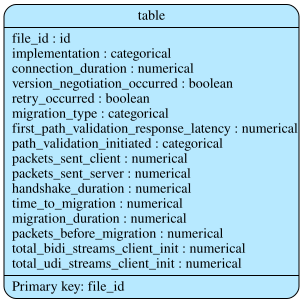

In [ ]:
metadata.visualize()

## Defining Constraints for the data

https://docs.sdv.dev/sdv/concepts/constraint-augmented-generation-cag

In [ ]:
from sdv.cag import Inequality

In [ ]:
constraint1 = Inequality(
    low_column_name='migration_duration',
    high_column_name='connection_duration',
    strict_boundaries=True
)
constraint2 = Inequality(
    low_column_name='handshake_duration',
    high_column_name='connection_duration',
    strict_boundaries=True
)

constraint3 = Inequality(
    low_column_name='first_path_validation_response_latency',
    high_column_name='connection_duration',
    strict_boundaries=True
)

## Optuna for Tuning

In [ ]:
%pip install optuna

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [ ]:
import optuna
from sdv.evaluation.single_table import run_diagnostic, evaluate_quality


In [ ]:
def objective(trial):
    """
    This function trains a CTGAN model with hyperparameters suggested by Optuna,
    evaluates it, and returns the quality score.
    """
    params = {
        'embedding_dim': trial.suggest_int('embedding_dim', 64, 256, step=64),
        'generator_dim': tuple([
            trial.suggest_int('g_dim_1', 128, 512, step=128),
            trial.suggest_int('g_dim_2', 128, 512, step=128)
        ]),
        'discriminator_dim': tuple([
            trial.suggest_int('d_dim_1', 128, 512, step=128),
            trial.suggest_int('d_dim_2', 128, 512, step=128)
        ]),
        'batch_size': trial.suggest_categorical('batch_size', [250, 500, 1000]),
        'epochs': trial.suggest_int('epochs', 500, 700, step=100)
    }

    model = CTGANSynthesizer(
        metadata = metadata,
        embedding_dim=params['embedding_dim'],
        generator_dim=params['generator_dim'],
        discriminator_dim=params['discriminator_dim'],
        batch_size=params['batch_size'],
        epochs=params['epochs'],
        verbose=False,
        cuda = True
    )

    try:
        model.fit(high_level_features_training)

        synthetic_data = model.sample(num_rows=len(high_level_features_training))

        quality_report = evaluate_quality(real_data=high_level_features_training, synthetic_data=synthetic_data, metadata = metadata)
        quality_score = quality_report.get_score()

    except Exception as e:
        print(f"Trial failed with error: {e}")
        return 0.0

    return quality_score

In [ ]:
import mlflow
mlflow.autolog(disable=True)

In [ ]:
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=100)

[I 2025-12-02 18:03:30,302] A new study created in memory with name: no-name-8130c510-de02-4b95-b78d-6f47181ac6c4
/local_disk0/.ephemeral_nfs/envs/pythonEnv-115a6180-e639-450b-8de9-7a75e831fb8f/lib/python3.12/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-115a6180-e639-450b-8de9-7a75e831fb8f/lib/python3.12/site-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 160.10it/s]|
Column Shapes Score: 91.62%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 253.37it/s]|
Column Pair Trends Score: 64.89%



[I 2025-12-02 18:15:19,900] Trial 0 finished with value: 0.7825422652263518 and parameters: {'embedding_dim': 64, 'g_dim_1': 512, 'g_dim_2': 384, 'd_dim_1': 384, 'd_dim_2': 128, 'batch_size': 250, 'epochs': 600}. Best is trial 0 with value: 0.7825422652263518.


Overall Score (Average): 78.25%



/local_disk0/.ephemeral_nfs/envs/pythonEnv-115a6180-e639-450b-8de9-7a75e831fb8f/lib/python3.12/site-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


...

Overall Score (Average): 78.75%



/local_disk0/.ephemeral_nfs/envs/pythonEnv-115a6180-e639-450b-8de9-7a75e831fb8f/lib/python3.12/site-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 175.39it/s]|
Column Shapes Score: 91.22%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 252.81it/s]|
Column Pair Trends Score: 64.53%



[I 2025-12-03 12:34:56,366] Trial 99 finished with value: 0.7787924667997974 and parameters: {'embedding_dim': 256, 'g_dim_1': 384, 'g_dim_2': 384, 'd_dim_1': 384, 'd_dim_2': 256, 'batch_size': 500, 'epochs': 500}. Best is trial 63 with value: 0.7949175404902878.


Overall Score (Average): 77.88%



In [ ]:
print("Study finished!")
print("Best trial:")
best_trial = study.best_trial

print(f"  Value (Quality Score): {best_trial.value}")
print("  Best hyperparameters:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

best_params = study.best_params
print("\nBest parameters dictionary:", best_params)

Study finished!
Best trial:
  Value (Quality Score): 0.7949175404902878
  Best hyperparameters:
    embedding_dim: 128
    g_dim_1: 256
    g_dim_2: 512
    d_dim_1: 384
    d_dim_2: 512
    batch_size: 250
    epochs: 700

Best parameters dictionary: {'embedding_dim': 128, 'g_dim_1': 256, 'g_dim_2': 512, 'd_dim_1': 384, 'd_dim_2': 512, 'batch_size': 250, 'epochs': 700}


In [ ]:
print("Study finished!")
print("Best trial:")
best_trial = study.best_trial

print(f"  Value (Quality Score): {best_trial.value}")
print("  Best hyperparameters:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

best_params = study.best_params
print("\nBest parameters dictionary:", best_params)

Study finished!
Best trial:
  Value (Quality Score): 0.7949175404902878
  Best hyperparameters:
    embedding_dim: 128
    g_dim_1: 256
    g_dim_2: 512
    d_dim_1: 384
    d_dim_2: 512
    batch_size: 250
    epochs: 700

Best parameters dictionary: {'embedding_dim': 128, 'g_dim_1': 256, 'g_dim_2': 512, 'd_dim_1': 384, 'd_dim_2': 512, 'batch_size': 250, 'epochs': 700}


In [ ]:
# plot optimization history and parameter importances
optuna.visualization.plot_optimization_history(study).show()

optuna.visualization.plot_param_importances(study).show()

### Training CTGAN

In [ ]:
import torch

In [ ]:
if torch.cuda.is_available():
    print("GPU is available!")
    device = "cuda"
else:
    print("GPU not available, falling back to CPU.")
    device = "cpu"

GPU is available!


Best parameters dictionary: {'embedding_dim': 128, 'g_dim_1': 256, 'g_dim_2': 512, 'd_dim_1': 384, 'd_dim_2': 512, 'batch_size': 250, 'epochs': 700}

In [ ]:
synthesizer = CTGANSynthesizer(
    metadata=metadata,
    embedding_dim=128,
    generator_dim=(256, 512),
    discriminator_dim=(384, 512),
    batch_size=250,
    epochs=3000,
    verbose=True,
    cuda=True
)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-5f735085-4cf1-41c7-ac39-c86f995f32c8/lib/python3.12/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-5f735085-4cf1-41c7-ac39-c86f995f32c8/lib/python3.12/site-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


In [ ]:
synthesizer.add_constraints(constraints=[constraint1, constraint2, constraint3])

In [ ]:
high_level_features_training = high_level_features_training[high_level_features_training['connection_duration'] > 0]

In [ ]:
synthesizer.fit(high_level_features_training)

synthetic_data = synthesizer.sample(num_rows=12000)

Gen. (0.30) | Discrim. (0.11): 100%|██████████| 3000/3000 [54:57<00:00,  1.10s/it]


In [ ]:
synthesizer.save('my_ctgan_model.pkl')

print("Model saved successfully.")

Model saved successfully.


In [ ]:
synthetic_data.display()

file_id,implementation,connection_duration,version_negotiation_occurred,retry_occurred,migration_type,first_path_validation_response_latency,path_validation_initiated,packets_sent_client,packets_sent_server,handshake_duration,time_to_migration,migration_duration,packets_before_migration,total_bidi_streams_client_init,total_udi_streams_client_init
1323958,nginx,6.615995975934416,true,false,BEFORE_DOWNLOAD,0.02649702577803283,1.0,12,10,4.21024861339726,3.0536702180982305,0.5606612046916488,8,1,3
15205817,quiche,13.931459226315322,false,true,BEFORE_DOWNLOAD,0.48900029280596,1.0,13,12,7.266952536388498,7.739038502522851,0.8358081153324401,13,1,4
2489483,nginx,7.575180146146051,true,false,BEFORE_DOWNLOAD,0.04770201315671492,1.0,12,10,7.411548729090835,9.500148879852881,0.7108231916130875,8,1,3
8898376,nginx,6.884657595493137,true,false,BEFORE_DOWNLOAD,0.07197257943361508,1.0,12,10,3.1589190604696116,2.2581124870034266,0.7876577305394316,8,1,3
6696076,quicgo,2.5787642358047833,false,false,BEFORE_DOWNLOAD,0.050886592569503196,1.0,9,9,2.190017561820925,5.148204927209957,0.08828763491477135,11,1,1
12233313,quiche,18.962476547084616,true,true,BEFORE_DOWNLOAD,0.5761476329154027,1.0,13,12,4.809466241062978,6.932809797064399,0.8163778828077858,13,1,4
14544120,nginx,1164.721141952279,false,false,DURING_DOWNLOAD,0.40225660392946666,1.0,8,11,17.28439677777308,30.83133419175109,0.9882198257977334,10,1,4
8791820,nginx,7.7498811125399145,true,true,BEFORE_DOWNLOAD,0.06968444477145753,1.0,12,10,4.37685020987618,3.6722836668424277,0.6698464096556965,8,1,3
11279130,aioquic,1766.9100761413574,false,false,BEFORE_DOWNLOAD,1.620895496276222,1.0,12,13,13.144873456040793,698.3165835017005,1.7042392838235774,15,1,4
5384662,aioquic,981.2793654030718,false,false,AFTER_DOWNLOAD,0.3963094793902196,1.0,13,9,9.249275191459049,68.2321846985616,0.7904029111602221,12,1,4


In [ ]:
synthetic_data

,file_id,implementation,connection_duration,version_negotiation_occurred,retry_occurred,migration_type,first_path_validation_response_latency,path_validation_initiated,packets_sent_client,packets_sent_server,handshake_duration,time_to_migration,migration_duration,packets_before_migration,total_bidi_streams_client_init,total_udi_streams_client_init
0,1323958,nginx,6.615996,True,False,BEFORE_DOWNLOAD,0.026497,1.0,12,10,4.210249,3.053670,0.560661,8,1,3
1,15205817,quiche,13.931459,False,True,BEFORE_DOWNLOAD,0.489000,1.0,13,12,7.266953,7.739039,0.835808,13,1,4
2,2489483,nginx,7.575180,True,False,BEFORE_DOWNLOAD,0.047702,1.0,12,10,7.411549,9.500149,0.710823,8,1,3
3,8898376,nginx,6.884658,True,False,BEFORE_DOWNLOAD,0.071973,1.0,12,10,3.158919,2.258112,0.787658,8,1,3
4,6696076,quicgo,2.578764,False,False,BEFORE_DOWNLOAD,0.050887,1.0,9,9,2.190018,5.148205,0.088288,11,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,1352271,aioquic,7.349931,True,False,BEFORE_DOWNLOAD,0.043147,1.0,12,10,3.110520,2.155046,0.723724,8,1,3
11996,9914285,quiche,11.084797,True,True,BEFORE_DOWNLOAD,0.513857,1.0,14,12,7.766799,7.837149,0.788304,13,1,4
11997,10233997,nginx,2.286746,False,False,BEFORE_DOWNLOAD,0.111248,1.0,9,9,1.637936,0.205988,0.186683,11,1,1
11998,11718559,nginx,6.272999,True,False,BEFORE_DOWNLOAD,0.028247,1.0,12,10,2.684601,3.161007,0.525109,8,1,3


## Evaluation of the data

Using the sdv library for now

In [ ]:
from sdv.evaluation.single_table import run_diagnostic, evaluate_quality
from sdv.evaluation.single_table import get_column_plot

diagnostic = run_diagnostic(high_level_features_training, synthetic_data, metadata)

quality_report = evaluate_quality(high_level_features_training, synthetic_data, metadata)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 16/16 [00:00<00:00, 739.10it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 373.13it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 188.39it/s]|
Column Shapes Score: 94.82%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 249.59it/s]|
Column Pair Trends Score: 74.79%

Overall Score (Average): 84.81%



In [ ]:

quality_report.get_visualization(property_name = 'Column Shapes')

In [ ]:
quality_report.get_details(property_name = 'Column Shapes')

,Column,Metric,Score
0,implementation,TVComplement,0.969965
1,connection_duration,KSComplement,0.911825
2,version_negotiation_occurred,TVComplement,0.980715
3,retry_occurred,TVComplement,0.996876
4,migration_type,TVComplement,0.976369
5,first_path_validation_response_latency,KSComplement,0.873857
6,path_validation_initiated,TVComplement,0.999664
7,packets_sent_client,KSComplement,0.957270
8,packets_sent_server,KSComplement,0.984931
9,handshake_duration,KSComplement,0.888064


In [ ]:
quality_report.get_visualization(property_name = 'Column Pair Trends')

In [ ]:

quality_report.get_details(property_name = 'Column Pair Trends')

,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Error
0,implementation,connection_duration,ContingencySimilarity,0.874619,NaN,NaN,None
1,implementation,version_negotiation_occurred,ContingencySimilarity,0.778917,NaN,NaN,None
2,implementation,retry_occurred,ContingencySimilarity,0.902258,NaN,NaN,None
3,implementation,migration_type,ContingencySimilarity,0.919061,NaN,NaN,None
4,implementation,first_path_validation_response_latency,ContingencySimilarity,0.922288,NaN,NaN,None
...,...,...,...,...,...,...,...
100,migration_duration,total_bidi_streams_client_init,CorrelationSimilarity,NaN,NaN,NaN,ConstantInputError: The synthetic data in colu...
101,migration_duration,total_udi_streams_client_init,CorrelationSimilarity,0.983263,0.319090,0.285616,None
102,packets_before_migration,total_bidi_streams_client_init,CorrelationSimilarity,NaN,NaN,NaN,ConstantInputError: The synthetic data in colu...
103,packets_before_migration,total_udi_streams_client_init,CorrelationSimilarity,0.972483,0.076231,0.131266,None


In [ ]:
def show_column_plot(column_name:str, plot_type:str = None):
  fig = get_column_plot(
      real_data=high_level_features_training,
      synthetic_data=synthetic_data,
      metadata=metadata,
      column_name=column_name,
      plot_type=plot_type
  )

  fig.show()

In [ ]:
show_column_plot('connection_duration')

In [ ]:
show_column_plot('handshake_duration')

In [ ]:
show_column_plot('time_to_migration')

In [ ]:
show_column_plot('migration_duration')

In [ ]:

show_column_plot('implementation')

In [ ]:
show_column_plot('migration_type')

In [ ]:
show_column_plot('packets_before_migration')

In [ ]:
show_column_plot('packets_sent_server')


In [ ]:
show_column_plot('packets_sent_client')


## Using the saved model to grenerate data

In [ ]:
from sdv.utils import load_synthesizer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
synthesizer = load_synthesizer(
    filepath='/content/drive/My Drive/MAP/my_ctgan_model.pkl'
)

/usr/local/lib/python3.12/dist-packages/sdv/_utils.py:310: SDVVersionWarning: You are currently on SDV version 1.32.1 but this synthesizer was created on version 1.30.0. The latest bug fixes and features may not be available for this synthesizer. To see these enhancements, create and train a new synthesizer on this version.
  warnings.warn(message, SDVVersionWarning)


In [ ]:
synthetic_data = synthesizer.sample(num_rows=12000)

In [ ]:
synthetic_data.to_csv('/content/drive/My Drive/MAP/synthetic_data.csv', index=False)